 Step 1: Import Libraries and Load Dataset

We load the cleaned dataset which has already been preprocessed and is ready for machine learning models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv(r"C:\Users\New Moon\Documents\Prosensia_AI_ML_Internship\Prosensia-AI-and-ML-Sabeeka\week2\task6\features_v1.csv")
df.head()
print(f"dataset shape: {df.shape}")
print(f"\ncolumns:\n{list(df.columns)}")
print(f"\nsample:")
print(df.head())

dataset shape: (500, 17)

columns:
['order_date', 'category', 'city', 'sales', 'profit', 'year', 'month', 'day', 'day_of_week', 'quarter', 'is_holiday', 'category_Clothing', 'category_Electronics', 'category_Food', 'city_Islamabad', 'city_Karachi', 'city_Lahore']

sample:
   order_date     category       city  sales  profit  year  month  day  \
0  2025-01-01         Food    Karachi   4954     836  2025      1    1   
1  2025-01-02  Electronics    Karachi    342     908  2025      1    2   
2  2025-01-03         Food  Islamabad   2690     363  2025      1    3   
3  2025-01-04         Food    Karachi   1163     983  2025      1    4   
4  2025-01-05  Electronics     Lahore   4424     159  2025      1    5   

  day_of_week  quarter  is_holiday  category_Clothing  category_Electronics  \
0   Wednesday        1           1                  0                     0   
1    Thursday        1           0                  0                     1   
2      Friday        1           0           

In [3]:
print(df.columns)

Index(['order_date', 'category', 'city', 'sales', 'profit', 'year', 'month',
       'day', 'day_of_week', 'quarter', 'is_holiday', 'category_Clothing',
       'category_Electronics', 'category_Food', 'city_Islamabad',
       'city_Karachi', 'city_Lahore'],
      dtype='str')


Step 2: Data Cleaning

We remove unnecessary categorical and date-based columns to ensure the dataset contains only numeric values for model training.

In [4]:
df = df.loc[:, ~df.columns.duplicated()]

In [5]:
df["high_profit"] = (df["profit"] > df["profit"].median()).astype(int)

In [6]:
print(df.columns)

Index(['order_date', 'category', 'city', 'sales', 'profit', 'year', 'month',
       'day', 'day_of_week', 'quarter', 'is_holiday', 'category_Clothing',
       'category_Electronics', 'category_Food', 'city_Islamabad',
       'city_Karachi', 'city_Lahore', 'high_profit'],
      dtype='str')


Step 3: Create Target Variable

We define a binary target variable `high_profit` based on whether the sales value is above the median.
This converts the problem into a classification task.

In [7]:
X = df.drop("high_profit", axis=1)
y = df["high_profit"]

In [8]:
df = df.drop(columns=["order_date", "profit"], errors="ignore")

In [9]:
df.dtypes

category                  str
city                      str
sales                   int64
year                    int64
month                   int64
day                     int64
day_of_week               str
quarter                 int64
is_holiday              int64
category_Clothing       int64
category_Electronics    int64
category_Food           int64
city_Islamabad          int64
city_Karachi            int64
city_Lahore             int64
high_profit             int64
dtype: object

In [10]:
df = df.drop(columns=["city", "category", "day_of_week"], errors="ignore")
df.head()

,sales,year,month,day,quarter,is_holiday,category_Clothing,category_Electronics,category_Food,city_Islamabad,city_Karachi,city_Lahore,high_profit
0,4954,2025,1,1,1,1,0,0,1,0,1,0,1
1,342,2025,1,2,1,0,0,1,0,0,1,0,1
2,2690,2025,1,3,1,0,0,0,1,1,0,0,0
3,1163,2025,1,4,1,0,0,0,1,0,1,0,1
4,4424,2025,1,5,1,0,0,1,0,0,0,1,0


In [11]:
df["high_profit"] = (df.iloc[:, 0] > df.iloc[:, 0].median()).astype(int)

Step 4: Split Features and Target

We separate independent variables (X) and dependent variable (y) for model training.

In [12]:
X = df.drop("high_profit", axis=1)
y = df["high_profit"]

 Step 5: Train-Test Split

We split the dataset into training and testing sets using an 80/20 ratio.
Stratification ensures balanced class distribution.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

 Step 6: Model Selection

We use two supervised learning models:

- Random Forest Classifier (ensemble method)
- Logistic Regression (linear baseline model)

These models help compare performance between complex and simple approaches.

In [14]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
lr_model = LogisticRegression(max_iter=1000)

 Step 7: Cross Validation

We use Stratified K-Fold Cross Validation (k=5) to ensure stable and unbiased model evaluation across different data splits.

Step 8: Model Training

Both models are trained on the training dataset to learn patterns in the data.

In [15]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_scores = cross_val_score(rf_model, X_train, y_train, cv=skf)
print("Random Forest:", rf_scores.mean(), "+/-", rf_scores.std())

Random Forest: 0.9974999999999999 +/- 0.004999999999999982


In [16]:
lr_scores = cross_val_score(lr_model, X_train, y_train, cv=skf)
print("Logistic Regression:", lr_scores.mean(), "+/-", lr_scores.std())

Logistic Regression: 0.9974999999999999 +/- 0.004999999999999982


In [17]:
rf_model.fit(X_train, y_train)
lr_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

Step 9: Predictions

We generate predictions on the test dataset to evaluate model performance.

In [18]:
rf_pred = rf_model.predict(X_test)
lr_pred = lr_model.predict(X_test)

 Step 10: Model Evaluation

We evaluate models using:
- Precision
- Recall
- F1-score
- Confusion Matrix

These metrics help us understand model performance beyond simple accuracy.

Random Forest Report
              precision    recall  f1-score   support

           0       1.00      0.98      0.99        50
           1       0.98      1.00      0.99        50

    accuracy                           0.99       100
   macro avg       0.99      0.99      0.99       100
weighted avg       0.99      0.99      0.99       100



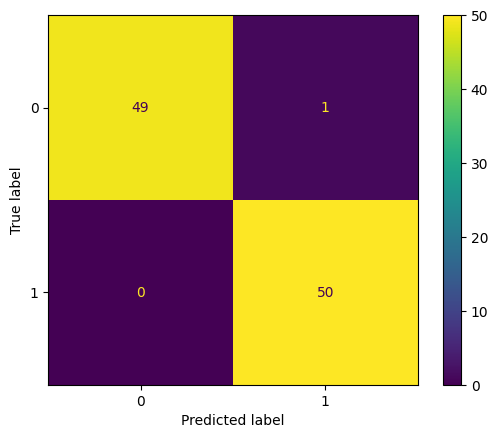

In [20]:
print("Random Forest Report")
print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.show()

Logistic Regression Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        50

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



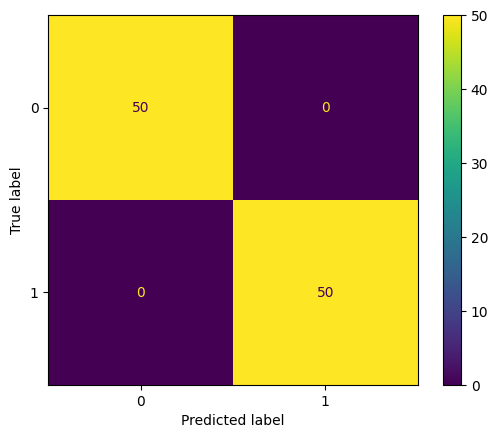

In [21]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

ConfusionMatrixDisplay.from_predictions(y_test, lr_pred)
plt.show()

In [23]:
joblib.dump(rf_model, "random_forest_model.pkl")
joblib.dump(lr_model, "logistic_regression_model.pkl")

['logistic_regression_model.pkl']

In [24]:
joblib.dump(rf_model, "random_forest_model.pkl")


['random_forest_model.pkl']